In [2]:
! pip install gyrointerp


  Using cached gyrointerp-0.7.tar.gz (13.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for gyrointerp: filename=gyrointerp-0.7-py3-none-any.whl size=11639383 sha256=8de07defbab5b138207fada2ed32382de1eb92c1f0123ca88c420c7a80fa7435
  Stored in directory: c:\users\smithlt\appdata\local\pip\cache\wheels\e7\a0\ef\3ea0b73084b2c4e0be463e5f70c775fdb6d30c188f329fceef
Successfully built gyrointerp


In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
import astropy.units as u
import gyrointerp
from gyrointerp import gyro_age_posterior
from gyrointerp import get_summary_statistics

targets = pd.read_csv("C:\\Users\\smithlt\\Documents\\ASTR502\\ASTR502_Mega_Target_List.csv")

In [3]:
#load the full mega target list
#had to move this to a separate directory because there were issues accessing the file from github
targets = pd.read_csv("C:\\Users\\smithlt\\Documents\\ASTR502\\ASTR502_Mega_Target_List.csv")

print(f"Loaded {len(targets)} total targets from CSV")
print(f"Columns available: {list(targets.columns)}")

# Check what mission sources we have
if 'mission_source' in targets.columns:
    print(f"\nMission sources in dataset:")
    print(targets['mission_source'].value_counts())
    
    # Filter for only Kepler targets
    kepler_targets = targets[targets['mission_source'] == 'Kepler'].copy()
    print(f"\nFound {len(kepler_targets)} Kepler targets!")
    
    if len(kepler_targets) > 0:
        print("\nFirst 10 Kepler targets:")
        for i, row in kepler_targets.head().iterrows():
            print(f"  {row['pl_name']}: {row['tic_id']}")
    else:
        print("No Kepler targets found in the dataset.")
        print("Let's check for targets that might have Kepler data...")
        
        # Look for targets that might have sy_kepmag (Kepler magnitude)
        if 'sy_kepmag' in targets.columns:
            kepler_mag_targets = targets[pd.notna(targets['sy_kepmag'])].copy()
            print(f"Found {len(kepler_mag_targets)} targets with Kepler magnitudes")
            if len(kepler_mag_targets) > 0:
                print("First 10 targets with Kepler magnitudes:")
                for i, row in kepler_mag_targets.head(10).iterrows():
                    print(f"  {row['pl_name']}: {row['tic_id']}, Kepler mag: {row['sy_kepmag']}")
                kepler_targets = kepler_mag_targets
else:
    print("No 'mission_source' column found. Let's look for other Kepler indicators...")
    
    # Look for targets that might have sy_kepmag
    if 'sy_kepmag' in targets.columns:
        kepler_targets = targets[pd.notna(targets['sy_kepmag'])].copy()
        print(f"Found {len(kepler_targets)} targets with Kepler magnitudes")
    else:
        print("No clear Kepler indicators found in the dataset.")
        kepler_targets = pd.DataFrame()

print(f"\nFinal Kepler target count: {len(kepler_targets)}")

# Test a few Kepler targets quickly to see what works
if len(kepler_targets) > 0:
    print("\nTesting search methods on first 10 Kepler targets...")
    test_sample = kepler_targets.head(10)
    
    working_kepler_targets = []
    
    for i, row in test_sample.iterrows():
        target_name = row['pl_name']
        tic_id = row['tic_id']
        
        print(f"\nTesting {target_name} ({tic_id}):")
        
        # Try different search strategies
        search_strategies = [
            f"{tic_id}",
            f"{tic_id}",
            target_name.split()[0] if len(target_name.split()) > 1 else target_name
        ]
        
        found_data = False
        for search_term in search_strategies:
            try:
                kepler_result = lk.search_lightcurve(search_term, author='Kepler')

                if len(kepler_result) > 0:
                    print(f"  '{search_term}': {len(kepler_result)} Kepler results")
                    working_kepler_targets.append({
                        'target_name': target_name,
                        'tic_id': tic_id,
                        'search_term': search_term,
                        'kepler_results': len(kepler_result),
                    })
                    found_data = True
                    break
                else:
                    print(f"  ✗ '{search_term}': No results")
            except Exception as e:
                print(f"  ✗ '{search_term}': Error - {e}")
        
        if not found_data:
            print(f"No data found for {target_name}")
    
    print(f"\n✓ Found {len(working_kepler_targets)} Kepler targets with available data")
    
    if working_kepler_targets:
        # DataFrame for processing
        kepler_star_df = pd.DataFrame(working_kepler_targets)
        print("\nReady to process these Kepler targets:")
        for i, row in kepler_star_df.iterrows():
            print(f"  {row['target_name']}: {row['search_term']} ({row['kepler_results']} Kepler)")
    else:
        print("No working Kepler targets found in the test sample")
else:
    print("No Kepler targets to test")

Loaded 4516 total targets from CSV
Columns available: ['pl_name', 'hostname', 'gaia_dr3_id', 'gaia_dr2_id', 'tic_id', 'hd_name', 'ra', 'dec', 'sy_vmag', 'sy_jmag', 'sy_kmag', 'sy_tmag', 'sy_kepmag', 'sy_gaiamag', 'st_teff', 'st_logg', 'st_met', 'st_mass', 'st_rad', 'st_spectype', 'st_lum', 'st_age', 'st_ageerr1', 'st_ageerr2', 'st_rotp', 'pl_orbper', 'pl_rade', 'pl_trandur', 'disc_facility', 'disc_year', 'mission_source']

Mission sources in dataset:
mission_source
Kepler    2762
TESS       717
K2         548
WASP       168
HAT        139
Other      105
CoRoT       34
NGTS        22
KELT        21
Name: count, dtype: int64

Found 2762 Kepler targets!

First 10 Kepler targets:
  Kepler-1629 b: TIC 351766445
  Kepler-1445 b: TIC 351766604
  Kepler-1286 b: TIC 351766517
  Kepler-1835 b: TIC 351799800
  Kepler-1341 b: TIC 123126460

Final Kepler target count: 2762

Testing search methods on first 10 Kepler targets...

Testing Kepler-1629 b (TIC 351766445):
  'TIC 351766445': 18 Kepler resu

Processing 10 Kepler targets with available data...

Processing target 1/10: Kepler-1629 b
TIC ID: TIC 351766445, Search term: TIC 351766445
Found 18 quarters of Kepler data


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:32 utils:127] 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


✓ Successfully downloaded Kepler lightcurve
  Time span: 120.5 - 130.2 days
  Data points: 473
  Clean data points: 469
  ✓ Period analysis complete:
    Peak period: 6.3801 days
    Peak power: 0.7350


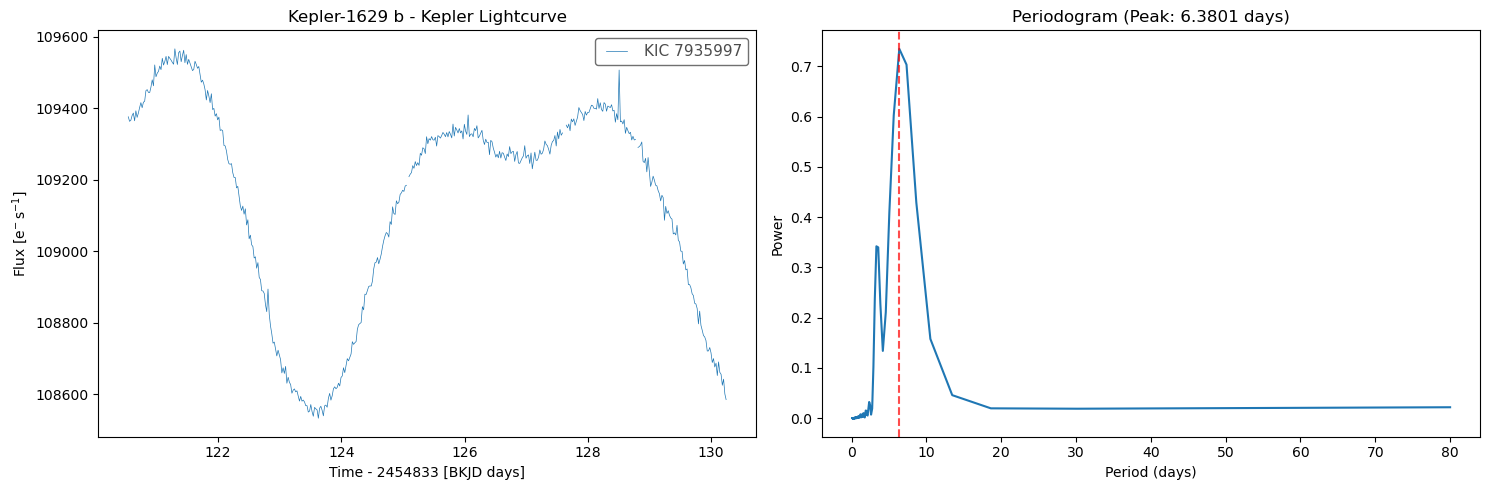


Processing target 2/10: Kepler-1445 b
TIC ID: TIC 351766604, Search term: TIC 351766604
Found 18 quarters of Kepler data


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:33 utils:127] 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


✓ Successfully downloaded Kepler lightcurve
  Time span: 120.5 - 130.2 days
  Data points: 473
  Clean data points: 469
  ✓ Period analysis complete:
    Peak period: 10.5351 days
    Peak power: 0.1896


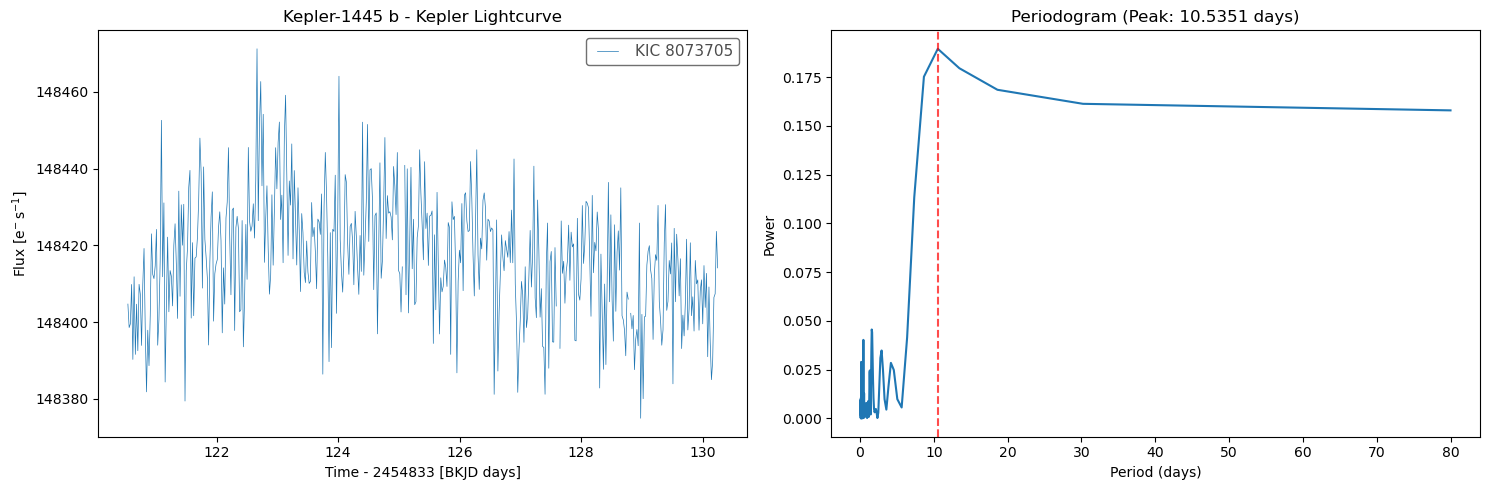

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:34 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 3/10: Kepler-1286 b
TIC ID: TIC 351766517, Search term: TIC 351766517
Found 9 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 20.6817 days
    Peak power: 0.0853


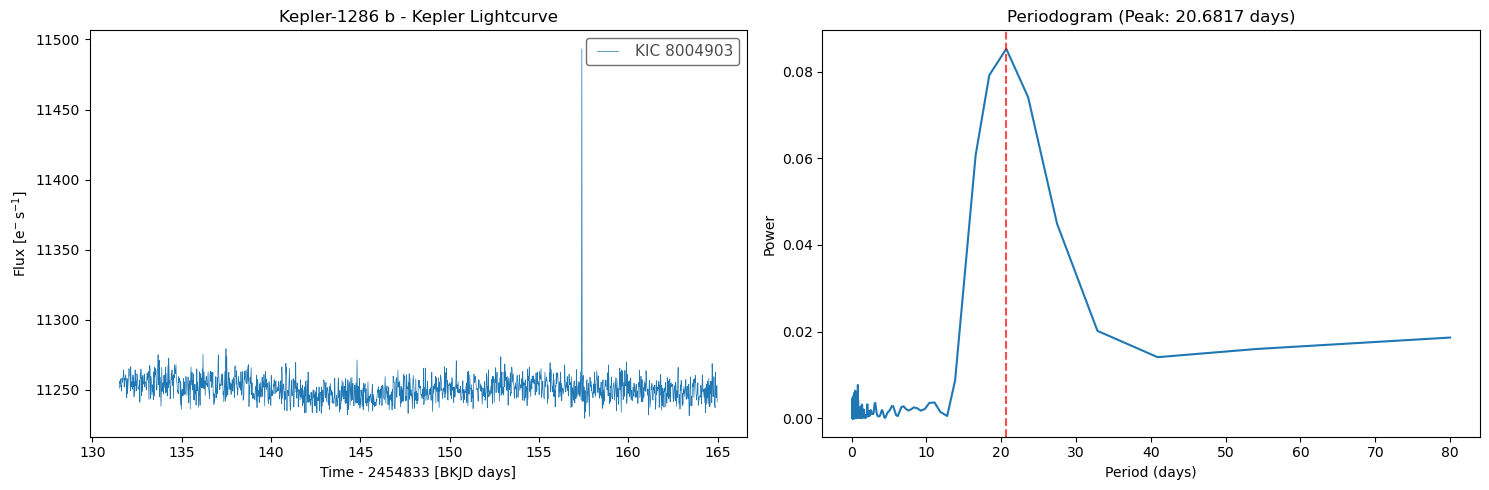

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:35 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 4/10: Kepler-1835 b
TIC ID: TIC 351799800, Search term: TIC 351799800
Found 9 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 80.0000 days
    Peak power: 0.0836


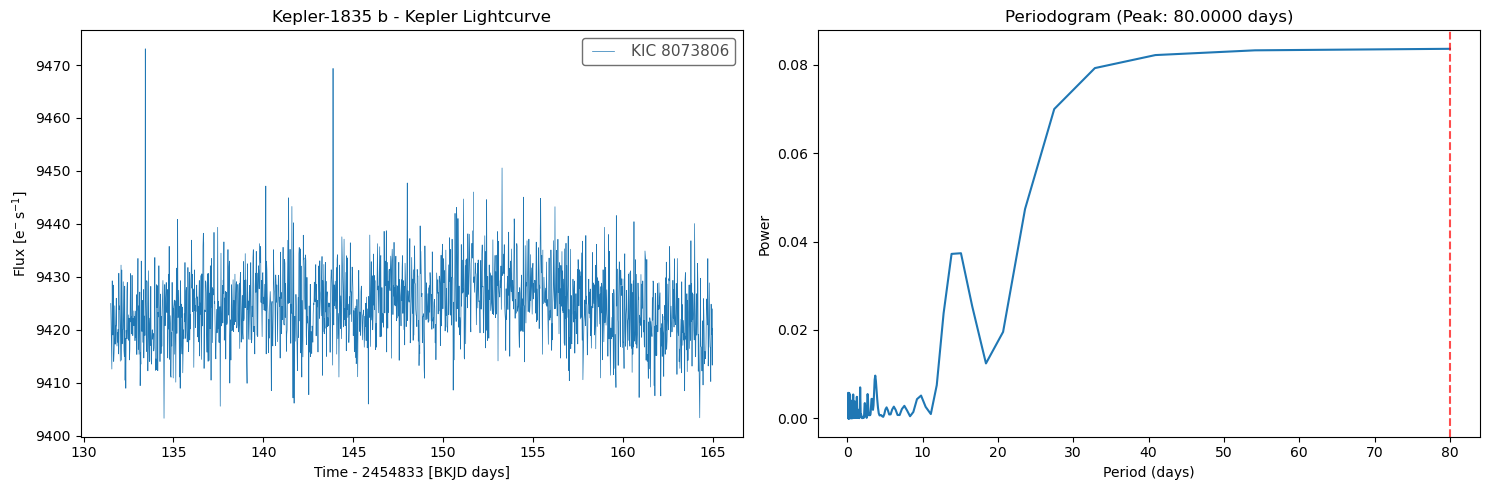

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:35 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 5/10: Kepler-1341 b
TIC ID: TIC 123126460, Search term: TIC 123126460
Found 17 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 23.5980 days
    Peak power: 0.8405


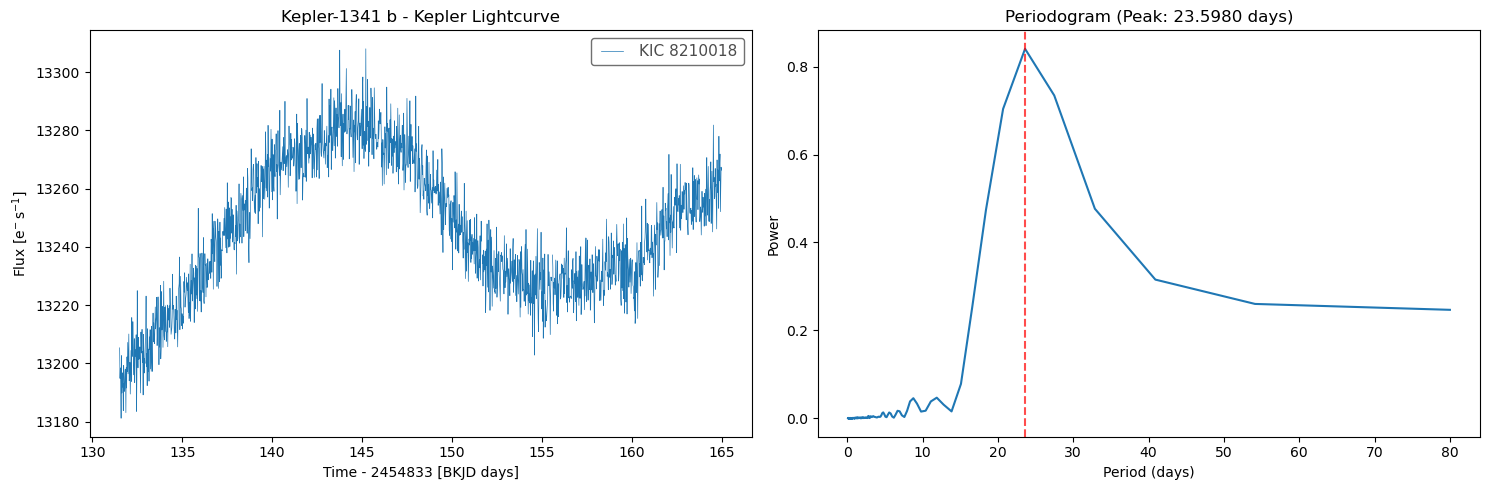

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:36 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 6/10: Kepler-589 b
TIC ID: TIC 123129910, Search term: TIC 123129910
Found 17 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 23.5979 days
    Peak power: 0.2376


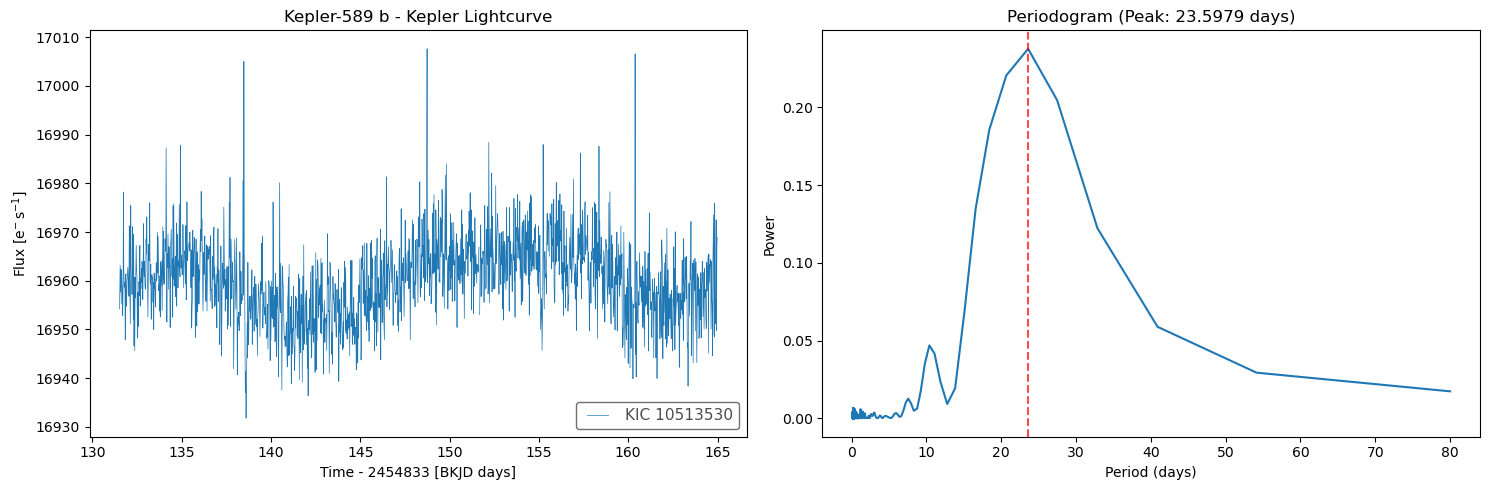

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:37 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 7/10: Kepler-589 c
TIC ID: TIC 123129910, Search term: TIC 123129910
Found 17 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 23.5979 days
    Peak power: 0.2376


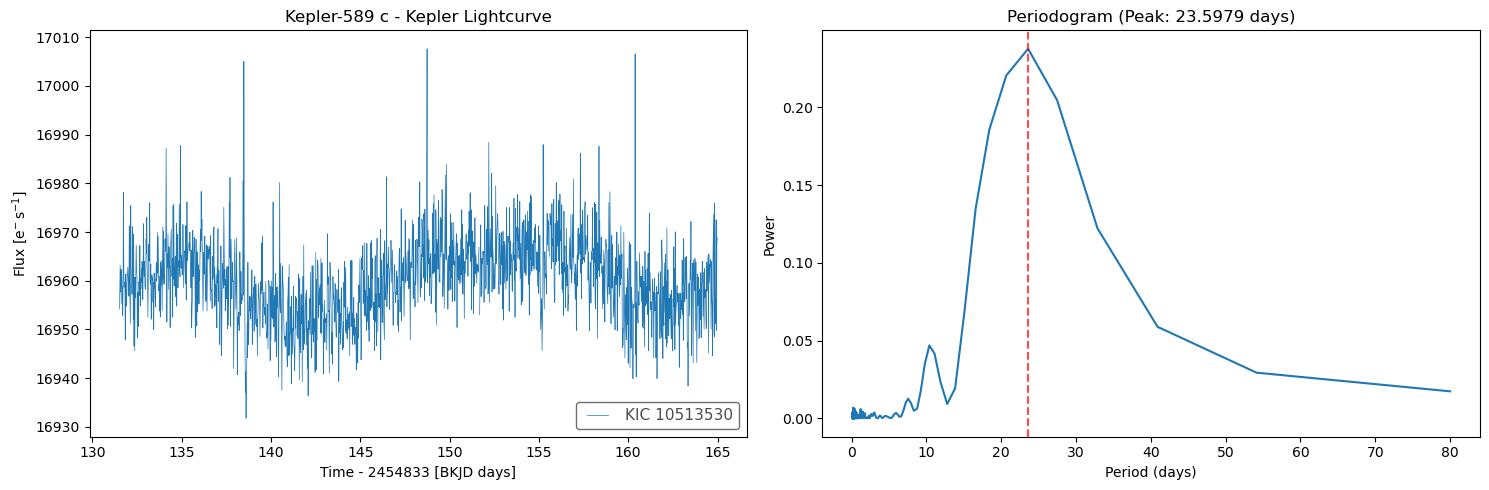

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:37 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 8/10: Kepler-165 c
TIC ID: TIC 123129877, Search term: TIC 123129877
Found 24 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 20.6817 days
    Peak power: 0.2856


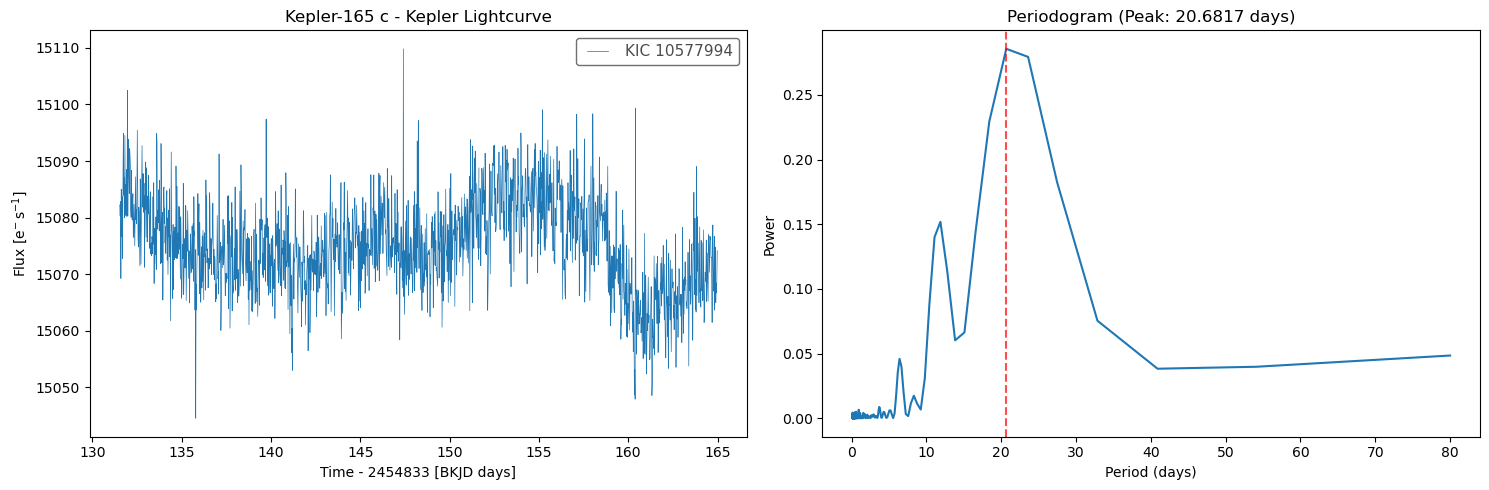

1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:38 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).



Processing target 9/10: Kepler-165 b
TIC ID: TIC 123129877, Search term: TIC 123129877
Found 24 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 20.6817 days
    Peak power: 0.2856


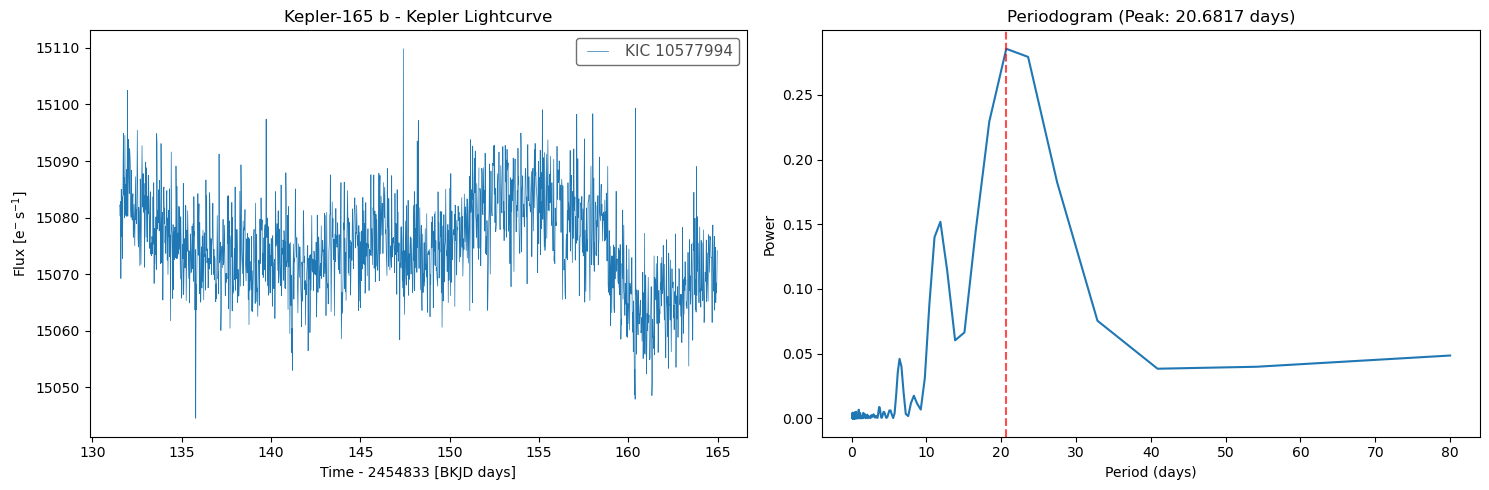


Processing target 10/10: Kepler-1907 c
TIC ID: TIC 123130285, Search term: TIC 123130285
Found 17 quarters of Kepler data


1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).
[I 260223 11:14:39 utils:127] 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 23.5979 days
    Peak power: 0.7487


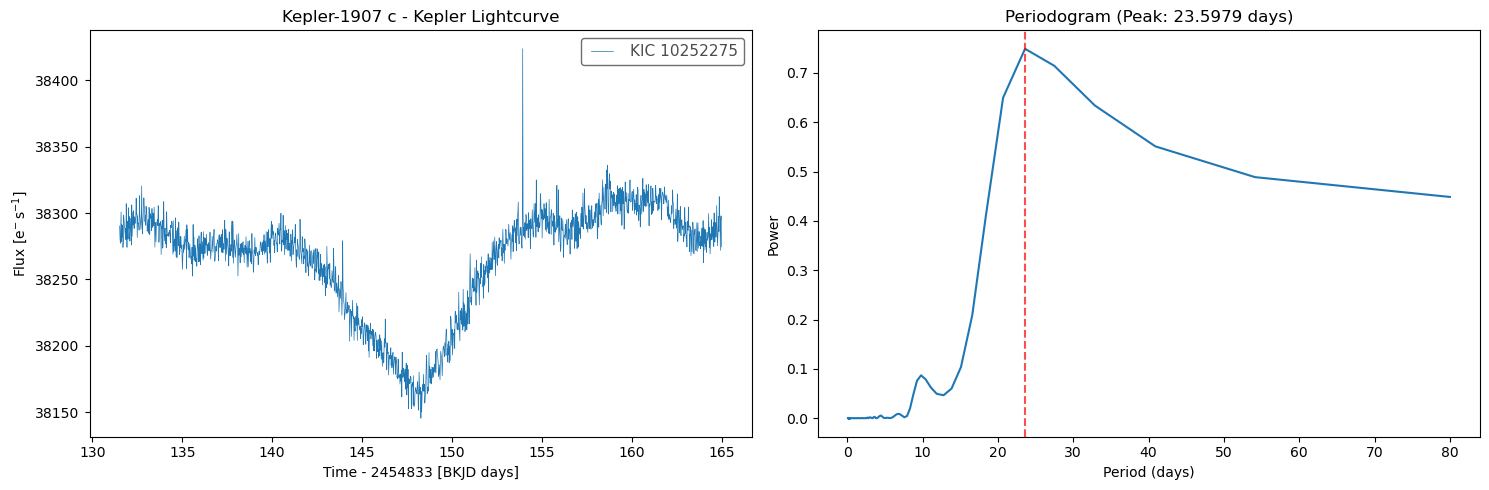


FINAL SUMMARY
Kepler targets processed: 10
Successful analyses: 10

Successful targets:
  Kepler-1629 b: 6.3801 days (Kepler)
  Kepler-1445 b: 10.5351 days (Kepler)
  Kepler-1286 b: 20.6817 days (Kepler)
  Kepler-1835 b: 80.0000 days (Kepler)
  Kepler-1341 b: 23.5980 days (Kepler)
  Kepler-589 b: 23.5979 days (Kepler)
  Kepler-589 c: 23.5979 days (Kepler)
  Kepler-165 c: 20.6817 days (Kepler)
  Kepler-165 b: 20.6817 days (Kepler)
  Kepler-1907 c: 23.5979 days (Kepler)

Period statistics:
  Average: 25.3352 days
  Range: 6.3801 - 80.0000 days
  Median: 22.1398 days


In [10]:
if 'kepler_star_df' in locals() and len(kepler_star_df) > 0:
    print(f"Processing {len(kepler_star_df)} Kepler targets with available data...")

    best_periods = []
    successful_analyses = 0
    target_results = []

    for i, row in kepler_star_df.iterrows():
        target_name = row['target_name'] 
        search_term = row['search_term']
        tic_id = row['tic_id']
        
        print(f"\n{'='*50}")
        print(f"Processing target {i+1}/{len(kepler_star_df)}: {target_name}")
        print(f"TIC ID: {tic_id}, Search term: {search_term}")
        
        try:
            # Search for Kepler 
            kepler_search = lk.search_lightcurve(search_term, author='Kepler')
            
            # Process Kepler data first if available
            if len(kepler_search) > 0:
                print(f"Found {len(kepler_search)} quarters of Kepler data")
                
                # Download first quarter only to keep it fast
                lc = kepler_search[0].download()
                
                if lc is not None:
                    mission_name = 'Kepler'
                    print(f"✓ Successfully downloaded Kepler lightcurve")
                    print(f"  Time span: {lc.time.min().value:.1f} - {lc.time.max().value:.1f} days")
                    print(f"  Data points: {len(lc.time)}")
                    
                    # process the lightcurve
                    time = lc.time.value if hasattr(lc.time, "value") else np.asarray(lc.time)
                    flux = lc.flux.value if hasattr(lc.flux, "value") else np.asarray(lc.flux)

                    # remove NaNs / infinities
                    mask = np.isfinite(time) & np.isfinite(flux)
                    clean_time = time[mask]
                    clean_flux = flux[mask]

                    
                    if len(clean_time) > 100:  #get enough points for analysis
                        print(f"  Clean data points: {len(clean_time)}")
                        
                        # Lomb-Scargle analysis
                        freq, power = LombScargle(clean_time, clean_flux).autopower(
                            minimum_frequency=1/80, maximum_frequency=10
                        )
                        
                        #find peak
                        peak_freq = freq[np.argmax(power)]
                        peak_period = 1/peak_freq
                        peak_power = np.max(power)
                        
                        print(f"  ✓ Period analysis complete:")
                        print(f"    Peak period: {peak_period:.4f} days")
                        print(f"    Peak power: {peak_power:.4f}")
                        
                        #store results
                        target_results.append({
                            'target_name': target_name,
                            'tic_id': tic_id,
                            'mission': mission_name,
                            'period': peak_period,
                            'power': peak_power,
                            'data_points': len(clean_time),
                            'Teff': row['st_teff'] if 'st_teff' in row else np.nan
                        })
                        
                        best_periods.append(peak_period)
                        successful_analyses += 1
                    
                        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
                        
                        #lightcurve plot
                        lc.plot(ax=ax1)
                        ax1.set_title(f'{target_name} - Kepler Lightcurve')
                        
                        # Periodogram
                        ax2.plot(1/freq, power)
                        ax2.set_xlabel('Period (days)')
                        ax2.set_ylabel('Power')
                        ax2.set_title(f'Periodogram (Peak: {peak_period:.4f} days)')
                        ax2.axvline(peak_period, color='red', linestyle='--', alpha=0.7)
                        
                        plt.tight_layout()
                        plt.show()
                        
                    else:
                        print(f"Not enough clean data points ({len(clean_time)})")
                else:
                    print(f"Failed to download Kepler data")
                    
        except Exception as e:
            print(f"Error processing {target_name}: {e}")
            continue

    #final summary
    print(f"\n{'='*50}")
    print(f"FINAL SUMMARY")
    print(f"{'='*50}")
    print(f"Kepler targets processed: {len(kepler_star_df)}")
    print(f"Successful analyses: {successful_analyses}")
    
    if target_results:
        results_df = pd.DataFrame(target_results)
        print(f"\nSuccessful targets:")
        for i, row in results_df.iterrows():
            print(f"  {row['target_name']}: {row['period']:.4f} days ({row['mission']})")
        
        if len(best_periods) > 1:
            print(f"\nPeriod statistics:")
            print(f"  Average: {np.mean(best_periods):.4f} days")
            print(f"  Range: {np.min(best_periods):.4f} - {np.max(best_periods):.4f} days")
            print(f"  Median: {np.median(best_periods):.4f} days")
    else:
        print("No successful analyses completed")
        
else:
    print("No Kepler targets available. Please run the previous cell first to identify Kepler targets.")

In [11]:
#find temperature header from Kepler targets
if 'st_teff' in kepler_targets.columns:
    teff_header = 'st_teff'
elif 'teff' in kepler_targets.columns:
    teff_header = 'teff'
else:
    teff_header = None

if teff_header:
    print(f"Found temperature header: {teff_header}")
else:
    print("No temperature header found.")

Found temperature header: st_teff


In [14]:
#find the effective temperature of the 10 targets processed
Teff = results_df['Teff']
Prot = results_df['period']

In [15]:
#cycle through all of the 10 targets and run gyrointerp
#print the age posterior calculated for each target

for i in range(len(results_df)):

    # units: days
    Prot, Prot_err = results_df['period'].iloc[i], 0.2

    # units: kelvin
    Teff, Teff_err = results_df['Teff'].iloc[i], 100

    # uniformly spaced grid between 0 and 2600 megayears
    age_grid = np.linspace(0, 2600, 500)

    # calculate the age posterior at each age in `age_grid`
    age_posterior = gyro_age_posterior(
        Prot, Teff,
        Prot_err=Prot_err, Teff_err=Teff_err,
        age_grid=age_grid
    )

    print(f"\nTarget: {results_df['target_name'].iloc[i]}")
    print(f"Age posterior (normalized): {age_posterior / np.sum(age_posterior)}")
    print(f"Age (most probable): {age_grid[np.argmax(age_posterior)]:.1f} Myr")


Target: Kepler-1629 b
Age posterior (normalized): [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan


KeyboardInterrupt: 